# K Studies

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

import os
import glob

In [2]:
# client = start_cluster(4, 32)
# client_ip_and_port(client)

In [4]:
m1_qcrad = xr.open_mfdataset(
    "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/station-data/qcrad1long/*.cdf",
)
m1_qcrad

<xarray.Dataset> Size: 278MB
Dimensions:                                (time: 940320)
Coordinates:
  * time                                   (time) datetime64[ns] 8MB 2021-09-...
Data variables: (12/70)
    base_time                              (time) datetime64[ns] 8MB 2021-09-...
    time_offset                            (time) datetime64[ns] 8MB dask.array<chunksize=(1440,), meta=np.ndarray>
    BestEstimate_down_short_hemisp         (time) float32 4MB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_BestEstimate_down_short_hemisp      (time) int32 4MB dask.array<chunksize=(1440,), meta=np.ndarray>
    source_BestEstimate_down_short_hemisp  (time) int32 4MB dask.array<chunksize=(1440,), meta=np.ndarray>
    down_short_hemisp                      (time) float32 4MB dask.array<chunksize=(1440,), meta=np.ndarray>
    ...                                     ...
    MFRSR_flag                             (time) int32 4MB dask.array<chunksize=(1440,), meta=np.ndarray>
    zenith                                 (time) float32 4MB dask.array<chunksize=(1440,), meta=np.ndarray>
    sun_earth_distance                     (time) float32 4MB dask.array<chunksize=(1440,), meta=np.ndarray>
    lat                                    (time) float32 4MB 38.96 ... 38.96
    lon                                    (time) float32 4MB -107.0 ... -107.0
    alt                                    (time) float32 4MB 2.886e+03 ... 2...
Attributes: (12/42)
    command_line:                        qcrad1long -n qcrad1long_sirsc2 -s g...
    Conventions:                         ARM-1.3
    process_version:                     vap-qcrad1long-6.8-0.el7
    dod_version:                         qcrad1long-c2-2.3
    input_datastreams:                   gucgndrad60sM1.b1 : 2.20 : 20210825....
    site_id:                             guc
    ...                                  ...
    Full_correction_dry_coefficient_b1:  0.017125
    Full_correction_dry_coefficient_b2:  1.037068
    Full_correction_wet_coefficient_b1:  0.041220
    Full_correction_wet_coefficient_b2:  1.047448
    configurable_limits:                 \ncnf0 = 16.0                * snow ...
    history:                             created by user howie on machine pro...

In [3]:
directory_m1_qcrad = "/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/station-data/qcrad1long/*.cdf"
m1_qcrad = xr.open_mfdataset(
    directory_m1_qcrad,
    preprocess=lambda ds: ds[['BestEstimate_down_short_hemisp', 'down_short_diffuse_hemisp', 'zenith']]
)
m1_qcrad = m1_qcrad.compute()
# preprocess - only save needed

In [4]:
m1_qcrad

<xarray.Dataset> Size: 19MB
Dimensions:                         (time: 940320)
Coordinates:
  * time                            (time) datetime64[ns] 8MB 2021-09-01 ... ...
Data variables:
    BestEstimate_down_short_hemisp  (time) float32 4MB 143.2 137.3 ... 102.0
    down_short_diffuse_hemisp       (time) float32 4MB 142.8 137.0 ... 102.4
    zenith                          (time) float32 4MB 71.56 71.75 ... 62.44
Attributes: (12/42)
    command_line:                        qcrad1long -n qcrad1long_sirsc2 -s g...
    Conventions:                         ARM-1.3
    process_version:                     vap-qcrad1long-6.8-0.el7
    dod_version:                         qcrad1long-c2-2.3
    input_datastreams:                   gucgndrad60sM1.b1 : 2.20 : 20210825....
    site_id:                             guc
    ...                                  ...
    Full_correction_dry_coefficient_b1:  0.017125
    Full_correction_dry_coefficient_b2:  1.037068
    Full_correction_wet_coefficient_b1:  0.041220
    Full_correction_wet_coefficient_b2:  1.047448
    configurable_limits:                 \ncnf0 = 16.0                * snow ...
    history:                             created by user howie on machine pro...

In [ ]:
# subset_sw_hourly = m1_qcrad['down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()
# subset_dif_hourly = m1_qcrad['down_short_diffuse_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()
# subset_dir_hourly = m1_qcrad['short_direct_normal'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()
# subset_best_hourly = m1_qcrad['BestEstimate_down_short_hemisp'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()
# # short dir normal - adjust for zenith angle...
# subset_zenith_hourly = m1_qcrad['zenith'].sel(time=slice("2021-10-01", "2022-06-30")).resample(time='1h').mean().load()

In [5]:
m1_obs_k = m1_qcrad['down_short_diffuse_hemisp'].clip(min=0) / m1_qcrad['BestEstimate_down_short_hemisp'].clip(min=0)
m1_obs_k = m1_obs_k.rename('k').clip(min=0, max=1)
# m1_obs_k = m1_obs_k.[ m1_qcrad['zenith'] < 90 ]
m1_obs_k = m1_obs_k.where( m1_qcrad['zenith'] < 90, 0)
m1_obs_k

# compare k values
# use cos_z at hourly time step

<xarray.DataArray 'k' (time: 940320)> Size: 4MB
array([0.9974248, 0.9972108, 0.9976545, ..., 1.       , 1.       ,
       1.       ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8MB 2021-09-01 ... 2023-06-15T23:59:00

In [60]:
m1_qcrad['zenith']

<xarray.DataArray 'zenith' (time: 940320)> Size: 4MB
array([71.55698 , 71.750565, 71.944176, ..., 62.05366 , 62.245605,
       62.437477], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8MB 2021-09-01 ... 2023-06-15T23:59:00
Attributes:
    long_name:      Solar Zenith Angle
    units:          degree
    comment:        Calculated using solarposition() function, by Nels Larson...
    standard_name:  solar_zenith_angle

In [6]:
m1_k = m1_obs_k.resample(time='1h').mean()


(np.float64(19052.0), np.float64(19056.0))

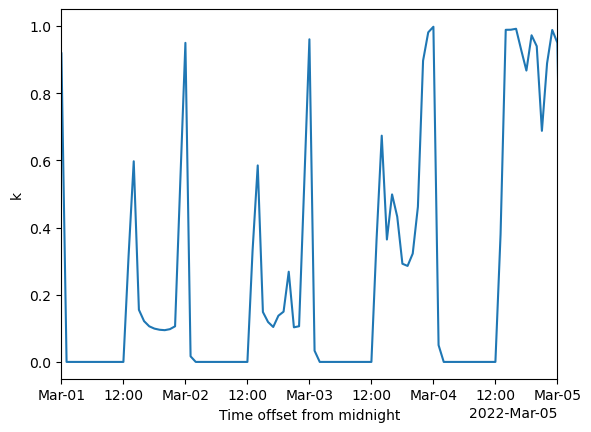

In [7]:
import datetime as dt

m1_k.plot()
plt.xlim(dt.datetime(2022, 3, 1), dt.datetime(2022, 3, 5))

(np.float64(19092.0), np.float64(19102.0))

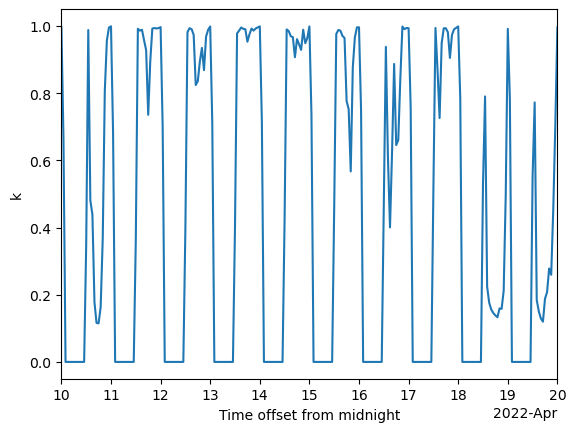

In [8]:
m1_k.plot()
plt.xlim(dt.datetime(2022, 4, 10), dt.datetime(2022, 4, 20))

In [9]:
# MODELEDE
save_dir = '../manuscript-2025/modeled-station-data'

m1_k_mod = xr.open_dataset(os.path.join(save_dir, 'm1_k.nc'))

In [10]:
m1_k_mod

<xarray.Dataset> Size: 88kB
Dimensions:  (time: 7320)
Coordinates:
    x        float32 4B ...
    y        float32 4B ...
  * time     (time) datetime64[ns] 59kB 2021-09-30T06:00:00 ... 2022-08-01T05...
Data variables:
    k        (time) float32 29kB ...

(np.float64(19092.0), np.float64(19102.0))

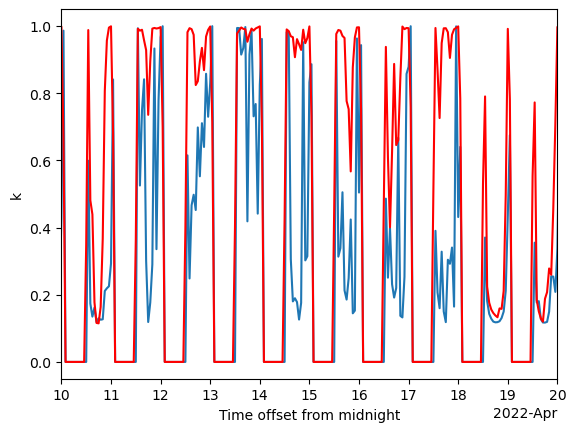

In [11]:
m1_k_mod['k'].plot()
m1_k.plot(color='red')
plt.xlim(dt.datetime(2022, 4, 10), dt.datetime(2022, 4, 20))

In [13]:
# start_time = dt.datetime(2022, 3, 1)
# end_time = dt.datetime(2022, 3, 10)
# k_mod_sub = m1_k_mod['k'].sel(time=slice(start_time, end_time)).clip
# k_obs_sub = m1_k.sel(time=slice(start_time, end_time))

# plt.scatter(k_obs_sub, k_mod_sub)


Text(0, 0.5, 'Modeled k')

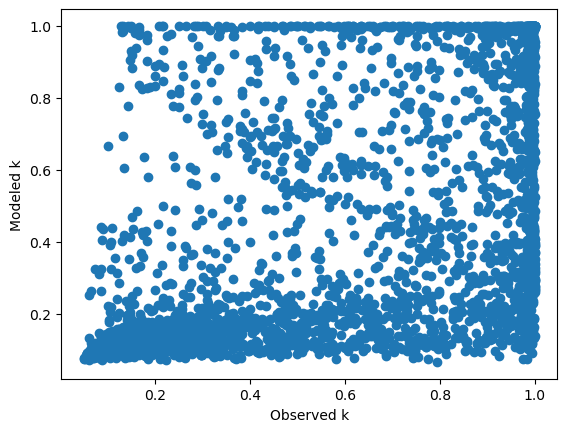

In [17]:
start_time = dt.datetime(2021, 10, 1)
end_time = dt.datetime(2022, 8, 1)
k_mod_sub = m1_k_mod['k'].sel(time=slice(start_time, end_time))
k_obs_sub = m1_k.sel(time=slice(start_time, end_time))

k_mod_sub = k_mod_sub.where(k_mod_sub > 0)
k_obs_sub = k_obs_sub.where(k_obs_sub > 0)

plt.scatter(k_obs_sub, k_mod_sub)
plt.xlabel("Observed k")
plt.ylabel("Modeled k")

# compare based on daily average k value (sky conditions)

In [19]:
k_obs_sub

<xarray.DataArray 'k' (time: 7297)> Size: 29kB
array([0.8337024 ,        nan,        nan, ..., 0.94655937, 0.9959821 ,
       0.9901853 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 58kB 2021-10-01 ... 2022-08-01

In [37]:
def to_local_mt(ds):
    # Convert to pandas datetime with timezone → then remove timezone
    mt = (
        pd.to_datetime(ds.time.values)
        .tz_localize("UTC")
        .tz_convert("US/Mountain")
        .tz_localize(None)                       # <-- remove timezone
    )

    # Convert back to numpy datetime64 so xarray can use .dt
    mt_np = mt.to_numpy()

    return (
        ds.assign_coords(time=("time", mt_np))
          # .swap_dims({"time": "time_mt"})
          # .drop_vars("time")
    )

In [49]:
# subset for time
start_time = dt.datetime(2021, 10, 1)
end_time = dt.datetime(2022, 8, 1)
k_mod_sub = m1_k_mod['k'].sel(time=slice(start_time, end_time))
k_obs_sub = m1_k.sel(time=slice(start_time, end_time))

# daylight hours only
k_mod_sub = k_mod_sub.where(k_mod_sub > 0)
k_obs_sub = k_obs_sub.where(k_obs_sub > 0)

# change to mt
k_mod_sub = to_local_mt(k_mod_sub)
k_obs_sub = to_local_mt(k_obs_sub)

# calculate daily mean for each
daily_obs = k_obs_sub.resample(time="1d").mean()
daily_mod = k_mod_sub.resample(time="1d").mean()

daily_obs_series = daily_obs.to_series()
daily_mod_series = daily_mod.to_series()

# simple classification
def categorize(val):
    return "<0.6" if val < 0.6 else "≥0.6"
# def categorize(val):
#     if val < 0.2:
#         return "<0.2"
#     elif val < 0.4:
#         return "0.2–0.4"
#     elif val < 0.6:
#         return "0.4–0.6"
#     elif val < 0.8:
#         return "0.6–0.8"
#     else:
#         return ">0.8"

dayo_category = daily_obs_series.apply(categorize)
# daym_category = daily_mod_series.apply(categorize) # NOT needed only use observed categorization


In [39]:
dayo_category

time
2021-09-30       >0.8
2021-10-01       >0.8
2021-10-02    0.6–0.8
2021-10-03    0.4–0.6
2021-10-04    0.2–0.4
               ...   
2022-07-27    0.6–0.8
2022-07-28       >0.8
2022-07-29       >0.8
2022-07-30    0.6–0.8
2022-07-31    0.6–0.8
Freq: D, Name: k, Length: 305, dtype: object

In [50]:
# convert back to xarray for alignment
dayo_category_xr = xr.DataArray(
    dayo_category,
    coords=[daily_obs.time],
    dims=["time"]
)
# daym_category_xr = xr.DataArray(
#     daym_category,
#     coords=[daily_mod.time],
#     dims=["time"]
# )
# align observed categories to model days (truth-based categorization)
daym_category_xr = xr.DataArray(
    dayo_category,
    coords=[daily_obs.time],
    dims=["time"]
)


# broadcast from daily to hourly
k_obs_sub2 = k_obs_sub.assign_coords(
    cld_type = dayo_category_xr.reindex(time=k_obs_sub.time, method="ffill"),
    hour=("time", k_obs_sub.time.dt.hour.data)
)
# k_mod_sub2 = k_mod_sub.assign_coords(
#     cld_type = daym_category_xr.reindex(time=k_mod_sub.time, method="ffill"),
#     hour=("time", k_mod_sub.time.dt.hour.data)
# )
# use observed
k_mod_sub2 = k_mod_sub.assign_coords(
    cld_type = daym_category_xr.reindex(time=k_mod_sub.time, method="ffill"),
    hour=("time", k_mod_sub.time.dt.hour.data)
)


# subset_nozero = subset_m1_obs_k.where(subset_m1_obs_k != 0)

# grouped = subset_m1_obs_k.groupby(("day_type", "hour"))
kobs_grouped = k_obs_sub2.groupby(("cld_type", "hour"))
kmod_grouped = k_mod_sub2.groupby(("cld_type", "hour"))

# stats
# ko_mean = kobs_grouped.mean()
# ko_std  = kobs_grouped.std()
# km_mean = kmod_grouped.mean()
# km_std  = kmod_grouped.std()
ko_mean = kobs_grouped.mean(skipna=True)
ko_std  = kobs_grouped.std(skipna=True)
km_mean = kmod_grouped.mean(skipna=True)
km_std  = kmod_grouped.std(skipna=True)


# rows = category, columns = 0–23
mean_dfo = ko_mean.to_series().unstack()   
std_dfo  = ko_std.to_series().unstack()
mean_dfm = km_mean.to_series().unstack()   
std_dfm  = km_std.to_series().unstack()


/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axi

In [51]:
mean_dfo

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cld_type,,,,,,,,,,,,,,,,,,,,,
<0.6,NaN,NaN,NaN,NaN,NaN,0.186540,0.700404,0.628410,0.295228,0.201592,...,0.239850,0.320937,0.517161,0.557248,0.710017,0.829119,0.411696,NaN,NaN,NaN
≥0.6,NaN,NaN,NaN,NaN,NaN,0.193365,0.661447,0.771502,0.785778,0.769244,...,0.832051,0.862886,0.879245,0.863918,0.794128,0.881850,0.441175,NaN,NaN,NaN


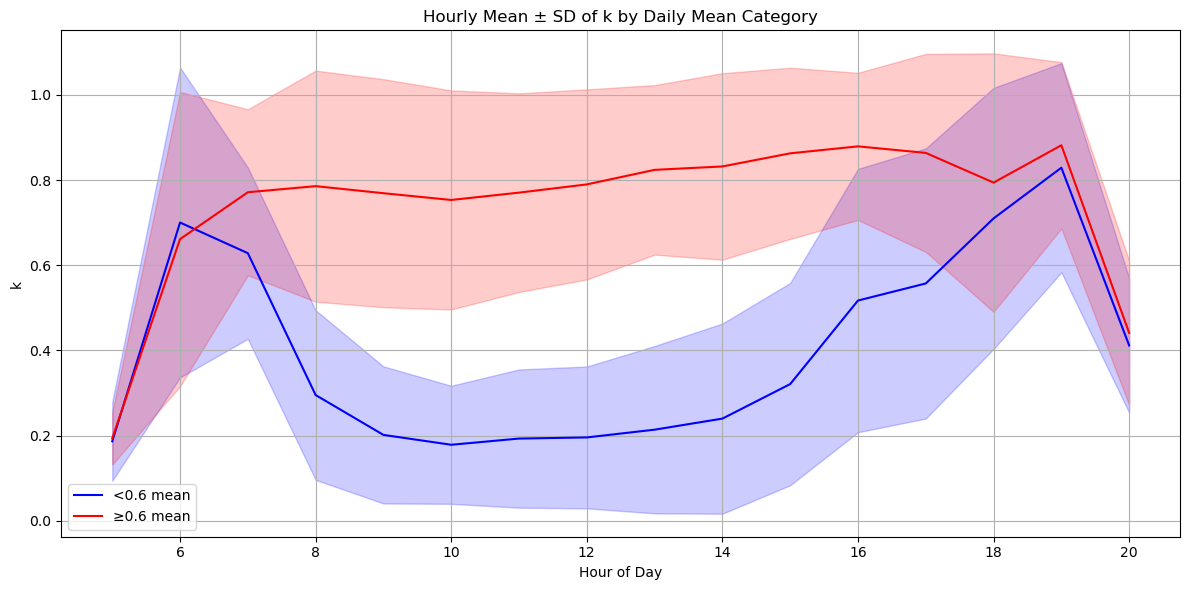

In [53]:
import matplotlib.pyplot as plt

# categories = ["<0.2", "0.2–0.4", "0.4–0.6", "0.6–0.8", ">0.8"]
# colors = ["blue", "green", "orange", "red", "purple"]
categories = ["<0.6", "≥0.6"]
colors = ["blue", "red"]

plt.figure(figsize=(12,6))

for cat, col in zip(categories, colors):
    if cat in mean_dfo.index:
        plt.plot(mean_dfo.columns, mean_dfo.loc[cat], label=f"{cat} mean", color=col)
        plt.fill_between(
            mean_dfo.columns,
            mean_dfo.loc[cat] - std_dfo.loc[cat],
            mean_dfo.loc[cat] + std_dfo.loc[cat],
            color=col, alpha=0.2
        )

plt.legend()
plt.xlabel("Hour of Day")
plt.ylabel("k")
plt.title("Hourly Mean ± SD of k by Daily Mean Category")
plt.grid(True)
plt.tight_layout()
plt.show()

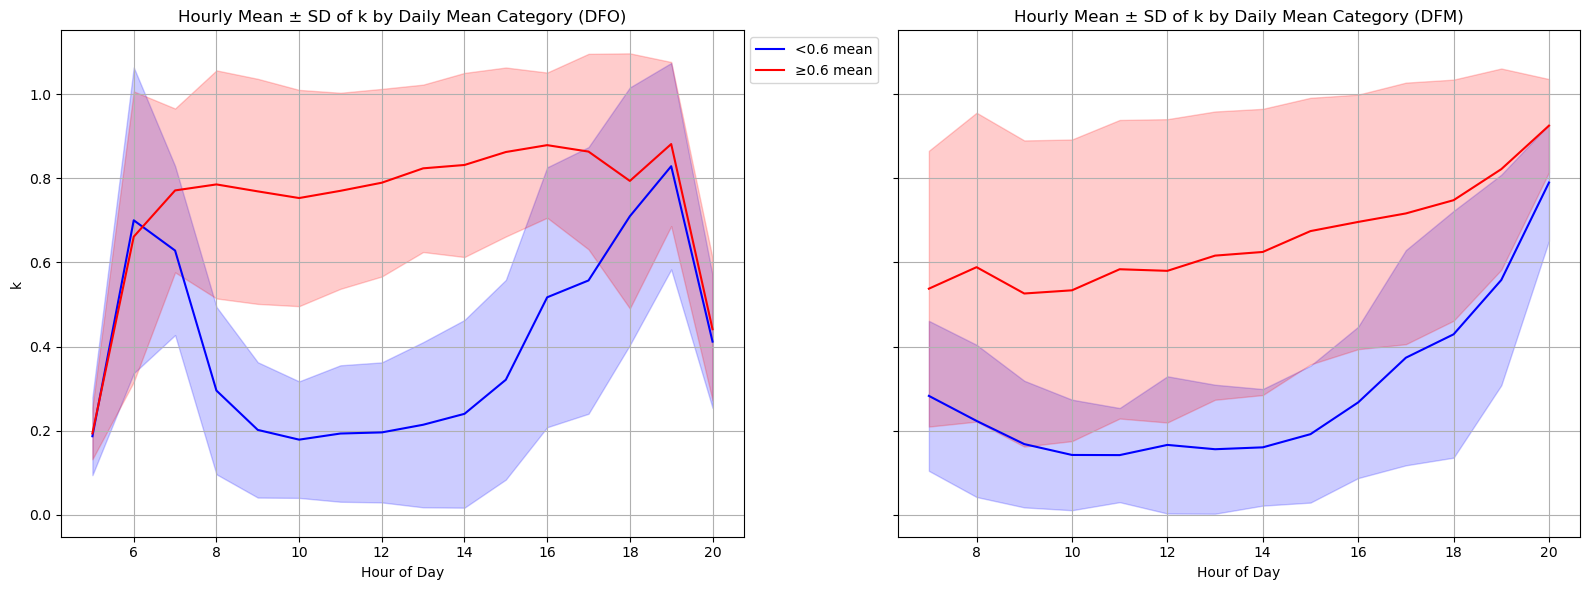

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

datasets = [
    ("Hourly Mean ± SD of k by Daily Mean Category (DFO)", mean_dfo, std_dfo, axes[0]),
    ("Hourly Mean ± SD of k by Daily Mean Category (DFM)", mean_dfm, std_dfm, axes[1])
]

for title, mean_df, std_df, ax in datasets:
    for cat, col in zip(categories, colors):
        if cat in mean_df.index:
            ax.plot(mean_df.columns, mean_df.loc[cat], label=f"{cat} mean", color=col)
            ax.fill_between(
                mean_df.columns,
                mean_df.loc[cat] - std_df.loc[cat],
                mean_df.loc[cat] + std_df.loc[cat],
                color=col, alpha=0.2
            )

    ax.set_title(title)
    ax.set_xlabel("Hour of Day")
    ax.grid(True)

# legend only once, on the first subplot or outside figure
axes[0].set_ylabel("k")
axes[0].legend(loc="upper left", bbox_to_anchor=(1, 1))  # move legend outside
plt.tight_layout()
plt.show()


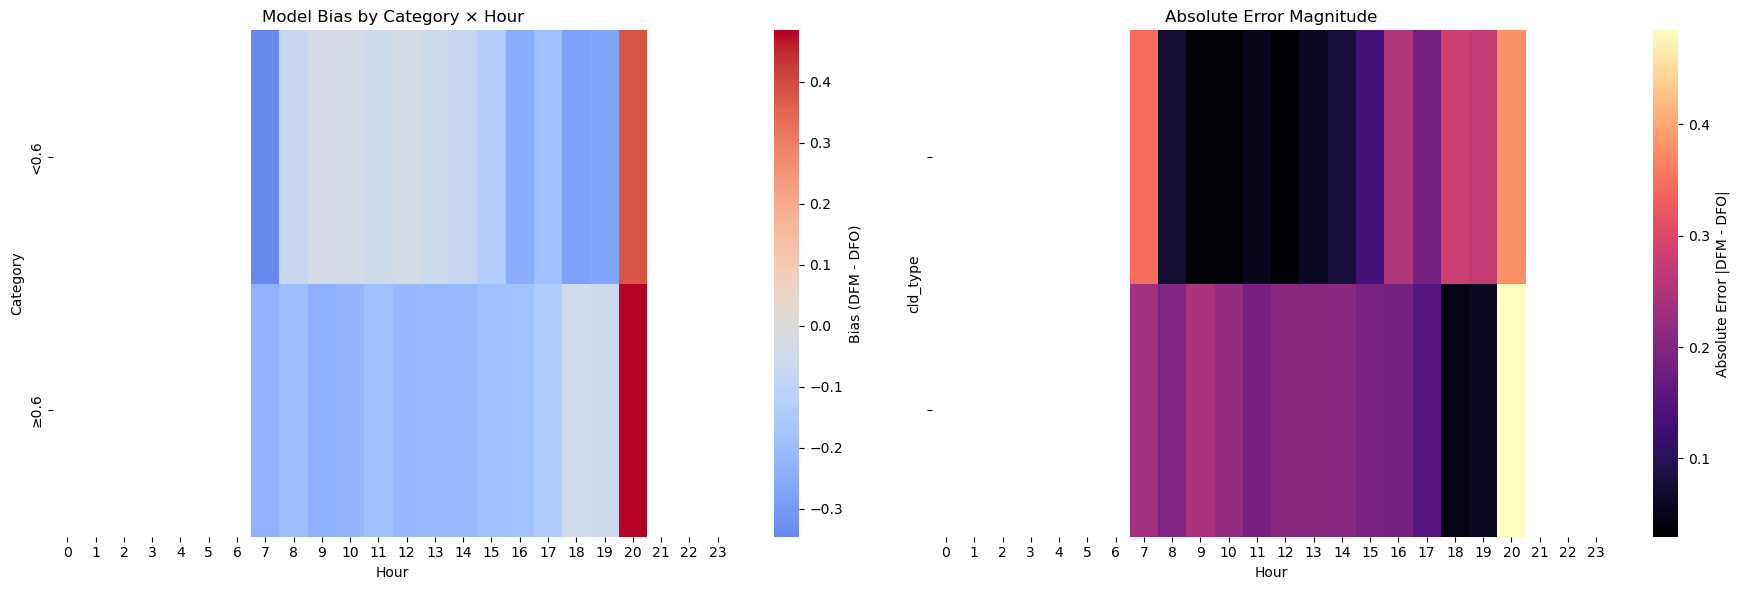

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute bias
bias = mean_dfm - mean_dfo     # same shape (category × hour)
abs_error = (mean_dfm - mean_dfo).abs()

fig, ax = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.heatmap(bias, cmap="coolwarm", center=0, annot=False,
            ax=ax[0], cbar_kws={"label": "Bias (DFM - DFO)"})
ax[0].set_title("Model Bias by Category × Hour")
ax[0].set_xlabel("Hour")
ax[0].set_ylabel("Category")

sns.heatmap(abs_error, cmap="magma", annot=False,
            ax=ax[1], cbar_kws={"label": "Absolute Error |DFM - DFO|"})
ax[1].set_title("Absolute Error Magnitude")
ax[1].set_xlabel("Hour")

plt.tight_layout()
plt.show()


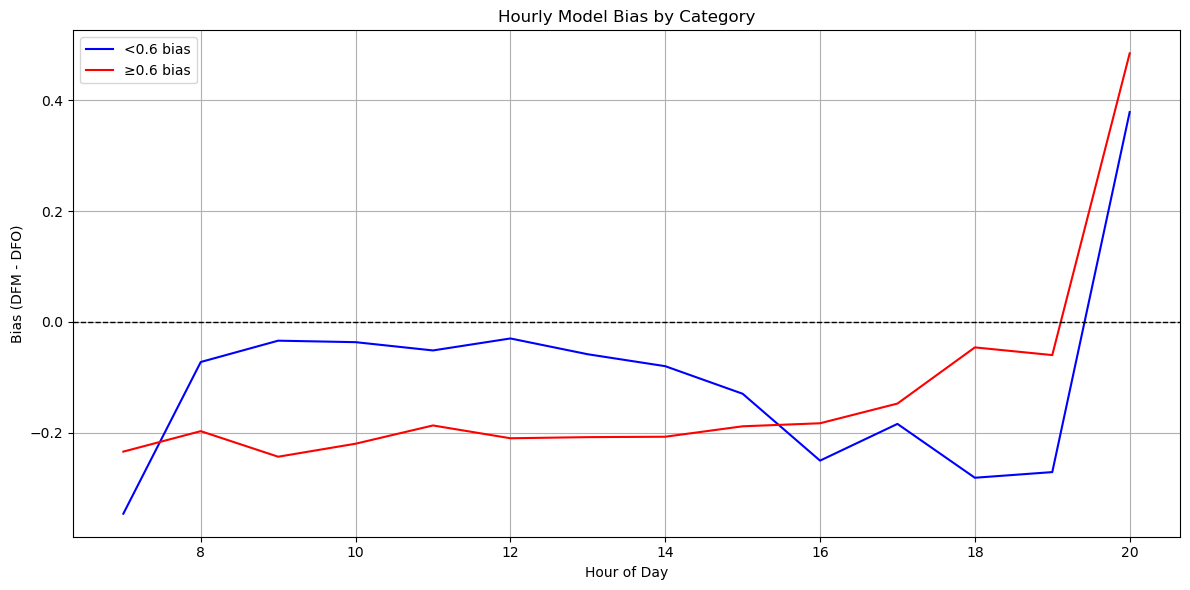

In [56]:
plt.figure(figsize=(12, 6))

for cat, col in zip(categories, colors):
    if cat in mean_dfo.index:
        hourly_bias = mean_dfm.loc[cat] - mean_dfo.loc[cat]
        plt.plot(hourly_bias.index, hourly_bias.values,
                 label=f"{cat} bias", color=col)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel("Hour of Day")
plt.ylabel("Bias (DFM - DFO)")
plt.title("Hourly Model Bias by Category")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axi

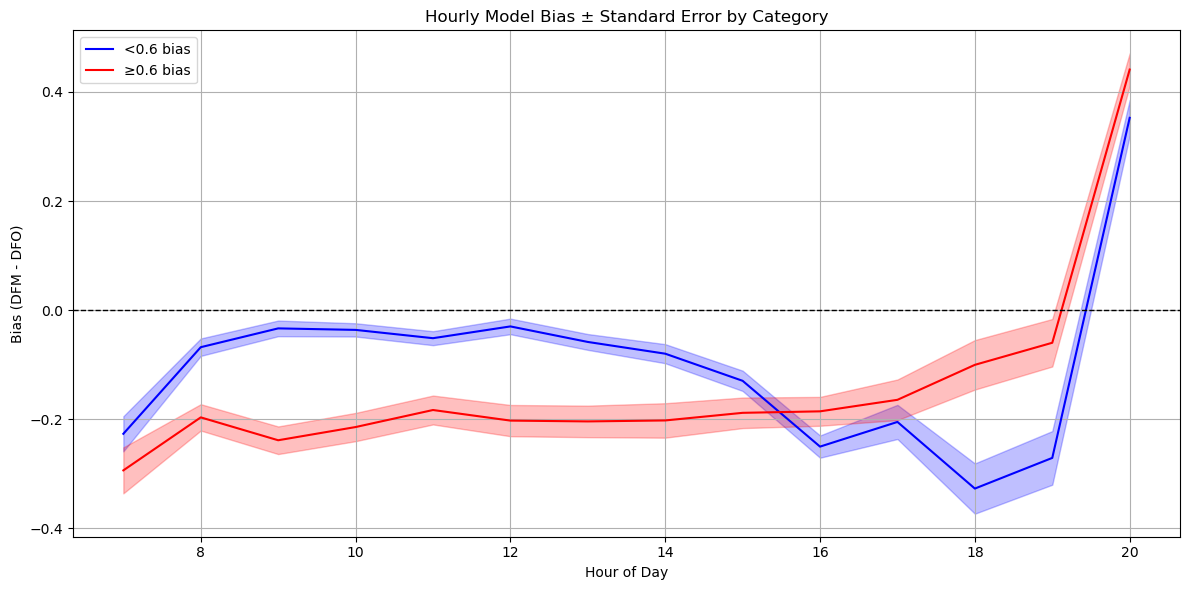

In [58]:
bias_ds = k_mod_sub2 - k_obs_sub2
bias_grouped = bias_ds.groupby(("cld_type", "hour"))

bias_mean = bias_grouped.mean(skipna=True)
bias_std  = bias_grouped.std(skipna=True)
bias_n    = bias_grouped.count()

bias_se = bias_std / np.sqrt(bias_n)
bias_mean_df = bias_mean.to_series().unstack()  # category × hour
bias_se_df   = bias_se.to_series().unstack()


plt.figure(figsize=(12, 6))

for cat, col in zip(categories, colors):
    if cat in bias_mean_df.index:
        mean_vals = bias_mean_df.loc[cat]
        se_vals   = bias_se_df.loc[cat]

        # Plot mean bias
        plt.plot(mean_vals.index, mean_vals.values,
                 label=f"{cat} bias", color=col)

        # Shaded standard error
        plt.fill_between(
            mean_vals.index,
            mean_vals - se_vals,
            mean_vals + se_vals,
            color=col,
            alpha=0.25        # lighter shading
        )

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel("Hour of Day")
plt.ylabel("Bias (DFM - DFO)")
plt.title("Hourly Model Bias ± Standard Error by Category")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


- Positive bias (> 0) Model overestimates k
- Negative bias (< 0) Model underestimates k

Underestimation at all hours except during final hour of daylight - regardless of cloud conditions

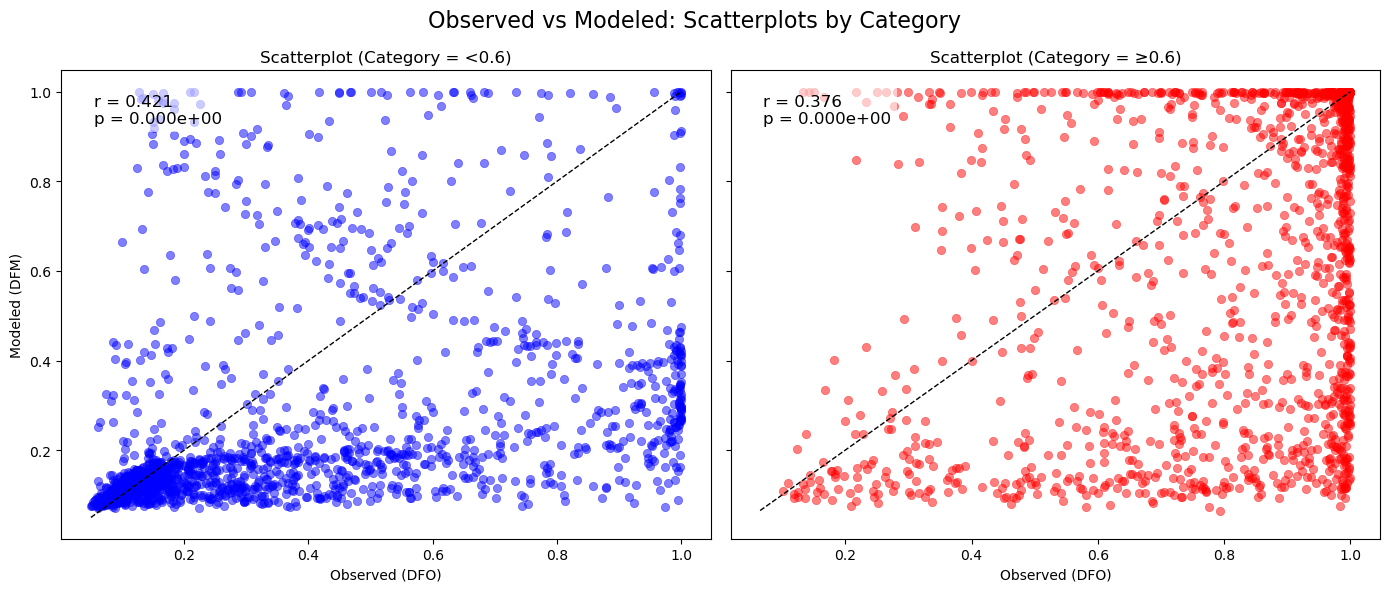

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Extract data into a pandas DataFrame for easy plotting
df = xr.Dataset({
    "obs": k_obs_sub2,
    "mod": k_mod_sub2,
    "category": k_obs_sub2.cld_type,
    "hour": k_obs_sub2.hour
}).to_dataframe().dropna()

categories = ["<0.6", "≥0.6"]
colors = ["blue", "red"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, cat, col in zip(axes, categories, colors):
    # Select category subset
    sub = df[df["category"] == cat]
    
    # Compute correlation
    if len(sub) > 1:
        r, p = pearsonr(sub["obs"], sub["mod"])
        corr_text = f"r = {r:.3f}\np = {p:.3e}"
    else:
        corr_text = "Not enough data"

    # Scatterplot
    sns.scatterplot(
        data=sub,
        x="obs",
        y="mod",
        alpha=0.5,
        color=col,
        edgecolor=None,
        ax=ax
    )

    # 1:1 reference line
    low = min(sub["obs"].min(), sub["mod"].min())
    high = max(sub["obs"].max(), sub["mod"].max())
    ax.plot([low, high], [low, high], "k--", linewidth=1)

    # Labels and title
    ax.set_title(f"Scatterplot (Category = {cat})")
    ax.set_xlabel("Observed (DFO)")
    ax.set_ylabel("Modeled (DFM)")
    
    # Add correlation text inside the panel
    ax.text(
        0.05, 0.95, corr_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

plt.suptitle("Observed vs Modeled: Scatterplots by Category", fontsize=16)
plt.tight_layout()
plt.show()


In [64]:
zenith_hourly.shape

(7297,)

In [72]:
import numpy as np
import pandas as pd
import xarray as xr

# --- 1. Add zenith angle to both observed and modeled hourly datasets ---
# Reindex zenith to hourly timestamps to match
zenith_hourly = m1_qcrad['zenith'].reindex(time=k_obs_sub2.time, method="nearest")

k_obs_zen = k_obs_sub2.assign_coords(
    zenith=("time", zenith_hourly.data)
)
k_mod_zen = k_mod_sub2.assign_coords(
    zenith=("time", zenith_hourly.data)
)


# --- 2. Apply zenith masking (mask > 90 degrees to zero or NaN as desired) ---
# If masking to zero, bias will be influenced. Prefer masking to NaN:
k_obs_zen = k_obs_zen.where(k_obs_zen.zenith < 90)
k_mod_zen = k_mod_zen.where(k_mod_zen.zenith < 90)

# --- 3. Compute bias dataset ---
bias_ds = k_mod_zen - k_obs_zen

# --- 4. Merge everything into a single dataframe ---
df = xr.Dataset({
    "obs": k_obs_zen,
    "mod": k_mod_zen,
    "bias": bias_ds,
    "zenith": k_obs_zen.zenith,
    "category": k_obs_zen.cld_type,
    "hour": k_obs_zen.hour
}).to_dataframe().dropna()

# --- 5. Zenith angle bins ---
# zen_bins = [0, 25, 50, 75, 90]
# zen_labels = ["0–25", "25–50", "50–75", "75–90"]
zen_bins = [0, 30, 60, 90]
zen_labels = ["0–30", "30–60", "60–90"]

df["zen_bin"] = pd.cut(df["zenith"], bins=zen_bins, labels=zen_labels, include_lowest=True)


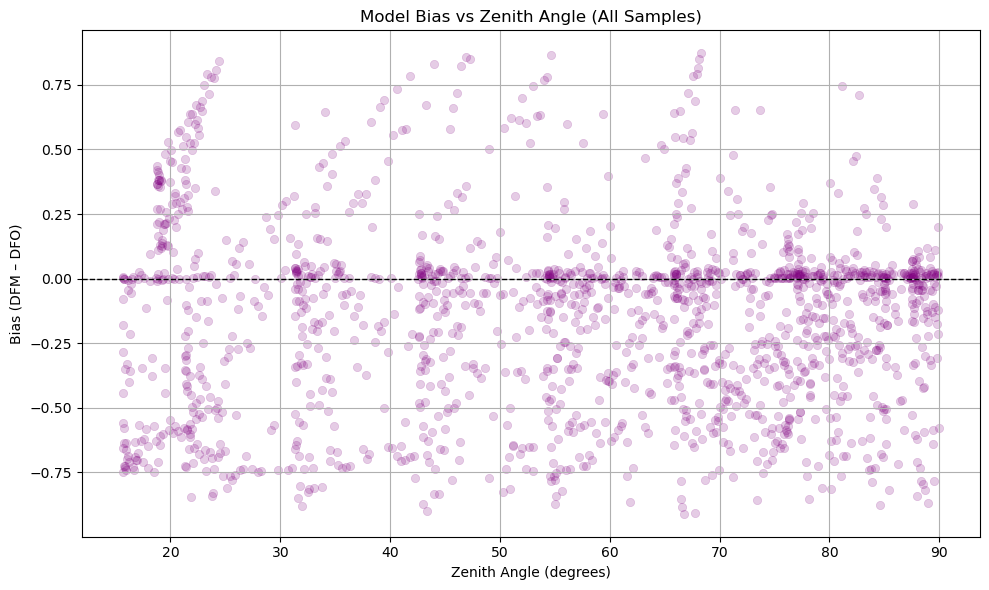

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="zenith",
    y="bias",
    alpha=0.2,
    color="purple",
    edgecolor=None
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Zenith Angle (degrees)")
plt.ylabel("Bias (DFM – DFO)")
plt.title("Model Bias vs Zenith Angle (All Samples)")
plt.grid(True)
plt.tight_layout()
plt.show()


/scratch/local/u1037042/9150661/ipykernel_2433782/196649424.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("zen_bin")


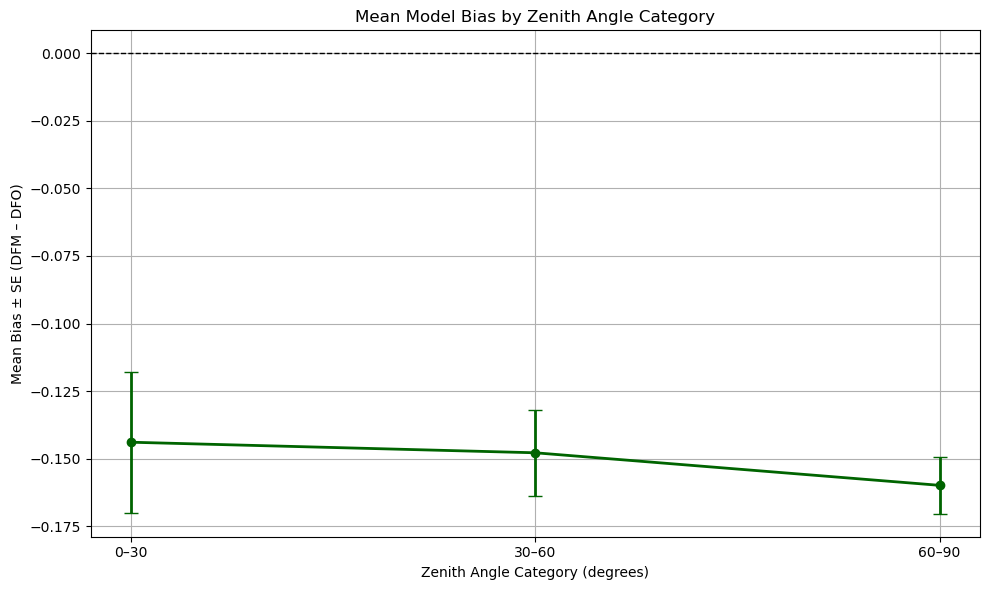

In [74]:
# Compute mean + standard error for each zenith category
grouped = df.groupby("zen_bin")

mean_bias = grouped["bias"].mean()
std_bias  = grouped["bias"].std()
n_bias    = grouped["bias"].count()

se_bias = std_bias / np.sqrt(n_bias)

# Plot
plt.figure(figsize=(10, 6))

plt.errorbar(
    x=zen_labels,
    y=mean_bias[zen_labels],
    yerr=se_bias[zen_labels],
    fmt="o-",
    color="darkgreen",
    capsize=5,
    linewidth=2
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Zenith Angle Category (degrees)")
plt.ylabel("Mean Bias ± SE (DFM – DFO)")
plt.title("Mean Model Bias by Zenith Angle Category")
plt.grid(True)
plt.tight_layout()
plt.show()


/scratch/local/u1037042/9150661/ipykernel_2433782/4041250451.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = sub.groupby("zen_bin")["bias"]
/scratch/local/u1037042/9150661/ipykernel_2433782/4041250451.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = sub.groupby("zen_bin")["bias"]


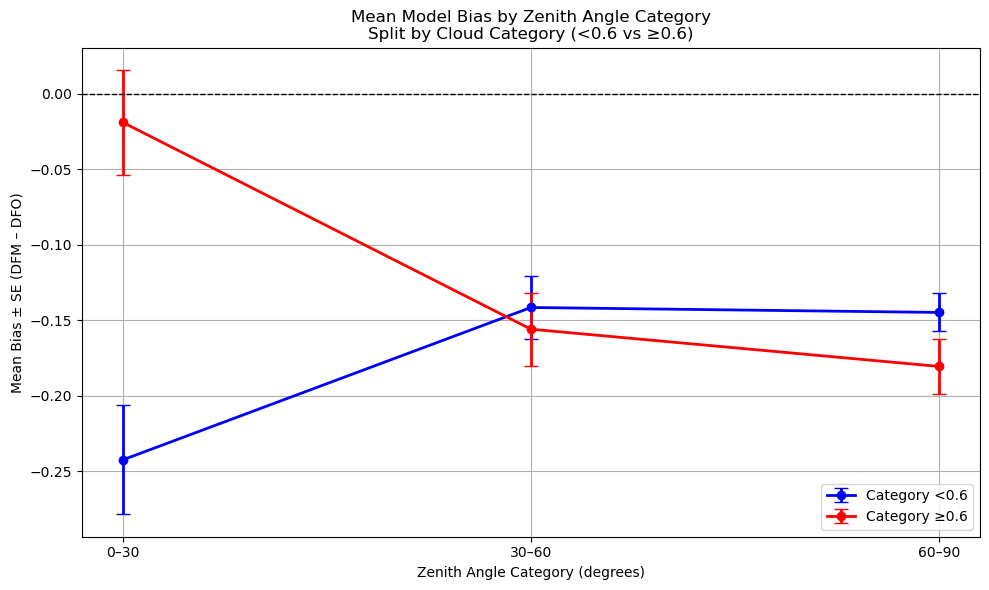

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure categories appear in correct order
categories = ["<0.6", "≥0.6"]
colors = ["blue", "red"]

# Pre-create the plot
plt.figure(figsize=(10, 6))

# Loop through categories
for cat, col in zip(categories, colors):
    # Select subset
    sub = df[df["category"] == cat]

    # Group by zenith bin
    grouped = sub.groupby("zen_bin")["bias"]

    # Mean, std, count → SE
    mean_bias = grouped.mean()
    std_bias  = grouped.std()
    n_bias    = grouped.count()
    se_bias   = std_bias / np.sqrt(n_bias)

    # Plot mean ± SE
    plt.errorbar(
        x=mean_bias.index.astype(str),   # ensure proper label display
        y=mean_bias.values,
        yerr=se_bias.values,
        fmt="o-",
        color=col,
        linewidth=2,
        capsize=5,
        label=f"Category {cat}"
    )

# Zero reference line
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# Labels
plt.xlabel("Zenith Angle Category (degrees)")
plt.ylabel("Mean Bias ± SE (DFM – DFO)")
plt.title("Mean Model Bias by Zenith Angle Category\nSplit by Cloud Category (<0.6 vs ≥0.6)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


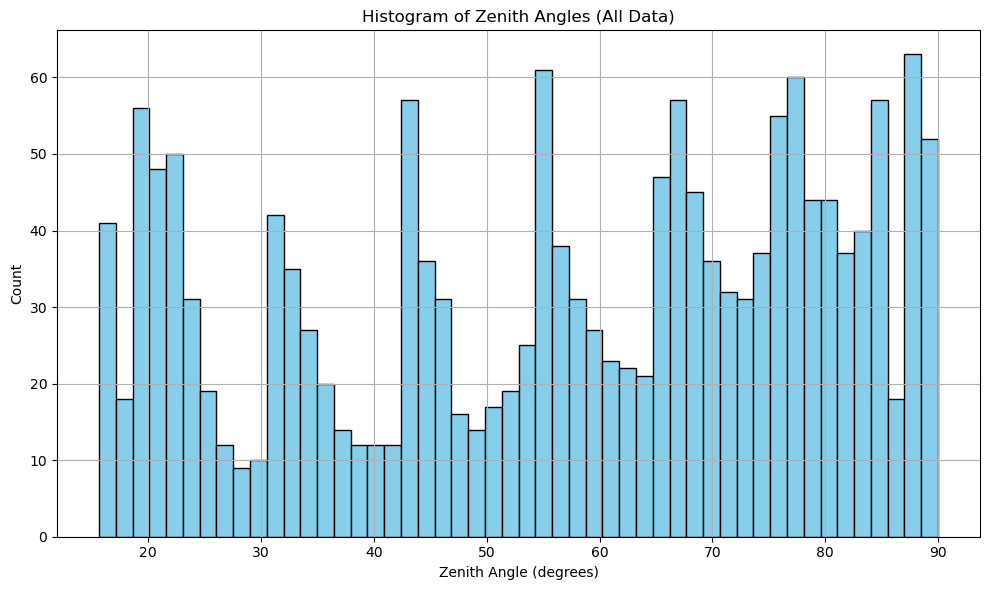

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["zenith"], bins=50, color="skyblue", edgecolor="k")
plt.xlabel("Zenith Angle (degrees)")
plt.ylabel("Count")
plt.title("Histogram of Zenith Angles (All Data)")
plt.grid(True)
plt.tight_layout()
plt.show()


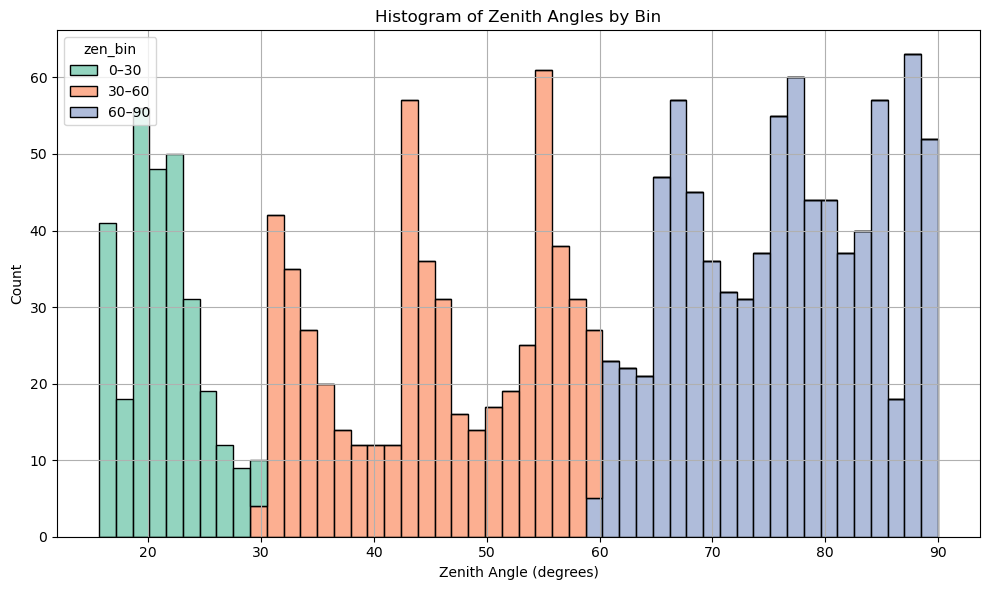

In [76]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# Countplot / histogram using the pre-defined zen_bins
sns.histplot(
    data=df,
    x="zenith",
    hue="zen_bin",
    bins=50,
    palette="Set2",
    multiple="stack",
    edgecolor="k",
    alpha=0.7
)

plt.xlabel("Zenith Angle (degrees)")
plt.ylabel("Count")
plt.title("Histogram of Zenith Angles by Bin")
plt.grid(True)
plt.tight_layout()
plt.show()


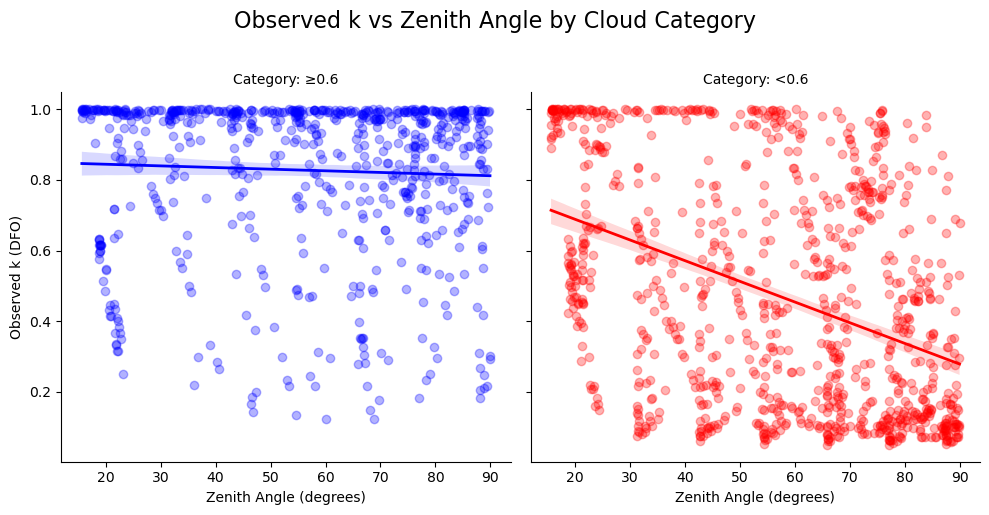

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure category is a string type
df["category"] = df["category"].astype(str)

# Create side-by-side scatterplots with linear regression
g = sns.lmplot(
    data=df,
    x="zenith",
    y="obs",
    col="category",           # split by category
    hue="category",           # color by category
    palette=["blue", "red"],
    height=5,
    aspect=1,
    scatter_kws={"alpha":0.3},
    line_kws={"linewidth":2}
)

g.set_axis_labels("Zenith Angle (degrees)", "Observed k (DFO)")
g.set_titles("Category: {col_name}")
g.fig.suptitle("Observed k vs Zenith Angle by Cloud Category", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [79]:
# Extract month from time
df['month'] = df.index.get_level_values('time').month  # numeric month 1–12
df['month_name'] = df['month'].apply(lambda x: pd.to_datetime(f'2023-{x}-01').strftime('%b'))


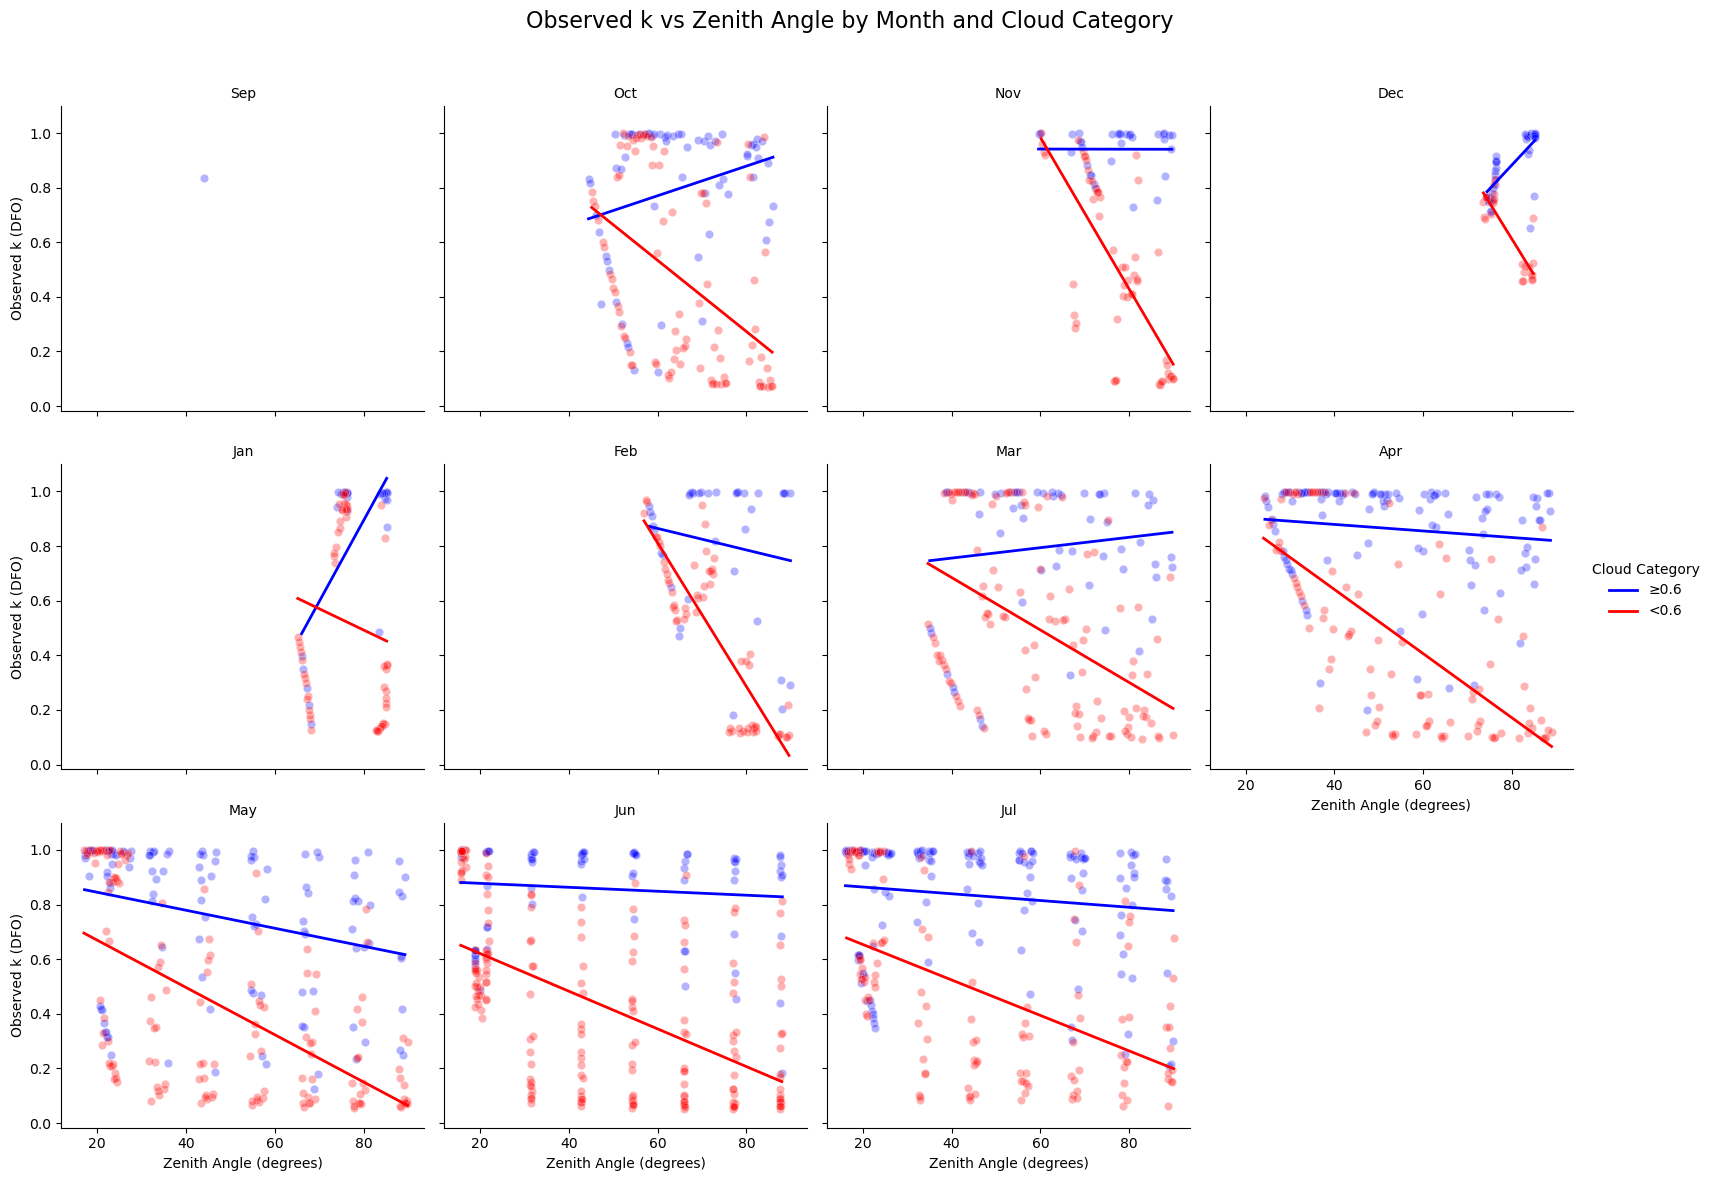

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

# Keep only months with enough data if desired
g = sns.FacetGrid(
    df,
    col="month_name",      # one column per month
    hue="category",        # color by cloud category
    col_wrap=4,            # wrap plots into multiple rows
    height=4,
    palette=["blue", "red"],
    sharex=True,
    sharey=True
)

g.map_dataframe(sns.scatterplot, x="zenith", y="obs", alpha=0.3)
g.map_dataframe(sns.regplot, x="zenith", y="obs", scatter=False, ci=None, line_kws={"linewidth":2})

g.add_legend(title="Cloud Category")
g.set_axis_labels("Zenith Angle (degrees)", "Observed k (DFO)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Observed k vs Zenith Angle by Month and Cloud Category", fontsize=16)
plt.show()
